In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_02_17/initialization_snspd')
SWEEP_FILE = 'snspd_sweep_freqs.csv'
FILE_FMT = 'snspd_sweep_{:02}.txt'
FREQ_START = 194824.456
FREQ_END = 194833.227
AOM_FREQ = 0.6  # measured frequency of data from snspd_sweep_freqs is detuned by this amount from actual freq

In [3]:
# read cavity data files
reference_scan_df = pd.read_csv(os.path.join(DATA_DIR, 'snspd_sweep_reference.txt'), sep='\t')
time = reference_scan_df['time(ps)']
freq = np.linspace(0, FREQ_END-FREQ_START, len(time))
sweep_df = pd.read_csv(os.path.join(DATA_DIR, SWEEP_FILE))
scan_dfs = {}
sweep_starts = {}
sweep_ends = {}

for row in sweep_df.iterrows():
    file_number = int(row[1]['File Number'])
    filename = FILE_FMT.format(file_number)
    df = pd.read_csv(os.path.join(DATA_DIR, filename), sep='\t')
    scan_dfs[file_number] = df

    sweep_start_freq = row[1]['Start Frequency (GHz)']
    sweep_end_freq = row[1]['End Frequency (GHz)']
    sweep_start_freq -= FREQ_START
    sweep_end_freq -= FREQ_START
    sweep_start_freq += AOM_FREQ
    sweep_end_freq += AOM_FREQ

    sweep_starts[file_number] = sweep_start_freq
    sweep_ends[file_number] = sweep_end_freq

In [4]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (7, 2)
dpi = 300
xlim = (2, 8)
ylim = (0, 12000)

color_memory = '#d95f02'

files_to_plot = (1, 4, 9)

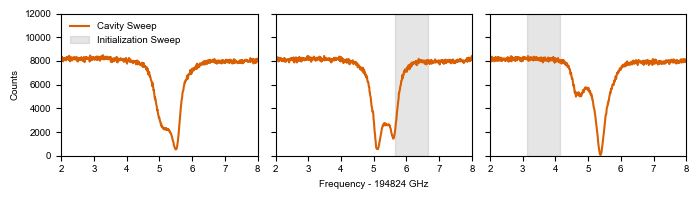

In [8]:
fig, axs = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, file_number in enumerate(files_to_plot):
    data_df = scan_dfs[file_number]
    axs[i].plot(freq, data_df['counts'],
                color=color_memory,
                label='Cavity Sweep')
    if i > 0:  # only plot sweeps if not the first (uninitialized) plot
        axs[i].axvspan(sweep_starts[file_number], sweep_ends[file_number],
                       alpha=0.2, color='gray', label='Initialization Sweep')
    else:  # make dummy span for legend purposes
        axs[i].axvspan(xlim[1] + 1, xlim[1] + 2,
                       alpha=0.2, color='gray', label='Initialization Sweep')
    axs[i].set_xlim(xlim)
    axs[i].set_ylim(ylim)

axs[0].legend(frameon=False, loc='upper left')
axs[0].set_ylabel('Counts')
axs[1].set_xlabel(f'Frequency - {FREQ_START:.0f} GHz')

fig.tight_layout()

In [9]:
fig.savefig('sup_initialization.pdf')